# **DOWNLOADING DATASET AND EDA**

Loading raw dataset: MustafaIbrahim/medical-arabic-qa...
Converting to Pandas DataFrame...

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52758 entries, 0 to 52757
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  52758 non-null  object
 1   answer    52657 non-null  object
 2   label     52758 non-null  object
dtypes: object(3)
memory usage: 1.2+ MB

--- Missing Values ---
question      0
answer      101
label         0
dtype: int64

--- First 5 Rows ---


,question,answer,label
0,\nما هي مميزات و عيوب الدواء جلوكوفانس 500 5 و...,\n\nلكل علاج ايجابيته وسلبياته والتي تعتمد على...,الدم
1,\nاليك نتيجة تحليل هرمونات الغدة الدرقية علما ...,\n\nنعم. يجب تخفيض الجرعة، الا اذا كان سبب است...,الاورام-الخبيثة-والحميدة
2,\nحلول منزلية لأعراض ارتفاع ضغط الدم,\n\nيفضل عدم الاستغناء عن العلاج الدوائي لمرضى...,جراحة-عامة
3,\nعملت عملية دوالي الساقين قسطرة الليزر من شهر...,\n\nراجع طبيبك من اجري الجراحه افضل من يجيب لا...,أمراض-الجهاز-التنفسي
4,\nما حقيقة ان تمرين العضلة النعلية يخفض السكر ...,\n\nإذا قصدت تدليك العضلة فهذا كلام غير صحيح ....,مرض-السكري


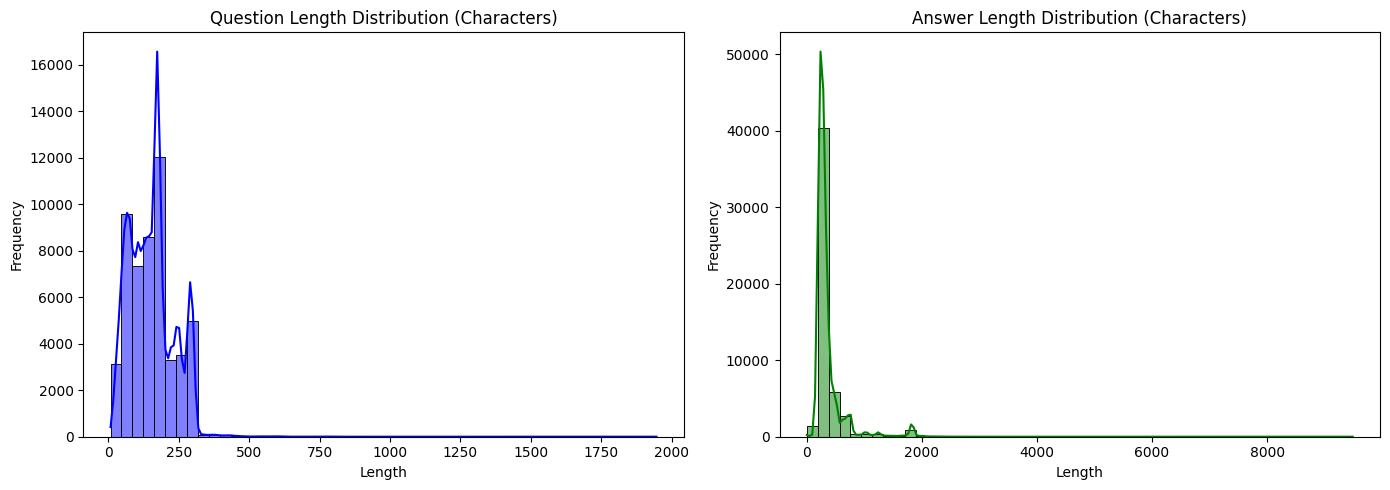

In [5]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# 1. Define the directory to be deleted
drive_path = "/content/drive/MyDrive/Medical_QA_Project"

# 3. Load the raw dataset
dataset_name = "MustafaIbrahim/medical-arabic-qa"
print(f"Loading raw dataset: {dataset_name}...")
dataset = load_dataset(dataset_name)

# 4. Convert the train split to a Pandas DataFrame for EDA
print("Converting to Pandas DataFrame...")
df = dataset['train'].to_pandas()

# 5. Exploratory Data Analysis (EDA)
print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isna().sum())

print("\n--- First 5 Rows ---")
display(df.head())

# 6. Feature Analysis: Calculate text lengths for questions and answers
cols = df.columns
if len(cols) >= 2:
    q_col = cols[0]
    a_col = cols[1]

    df['question_length'] = df[q_col].astype(str).apply(len)
    df['answer_length'] = df[a_col].astype(str).apply(len)

    # 7. Visualize the text length distributions
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df['question_length'], bins=50, color='blue', kde=True)
    plt.title('Question Length Distribution (Characters)')
    plt.xlabel('Length')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.histplot(df['answer_length'], bins=50, color='green', kde=True)
    plt.title('Answer Length Distribution (Characters)')
    plt.xlabel('Length')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

Calculating word counts...


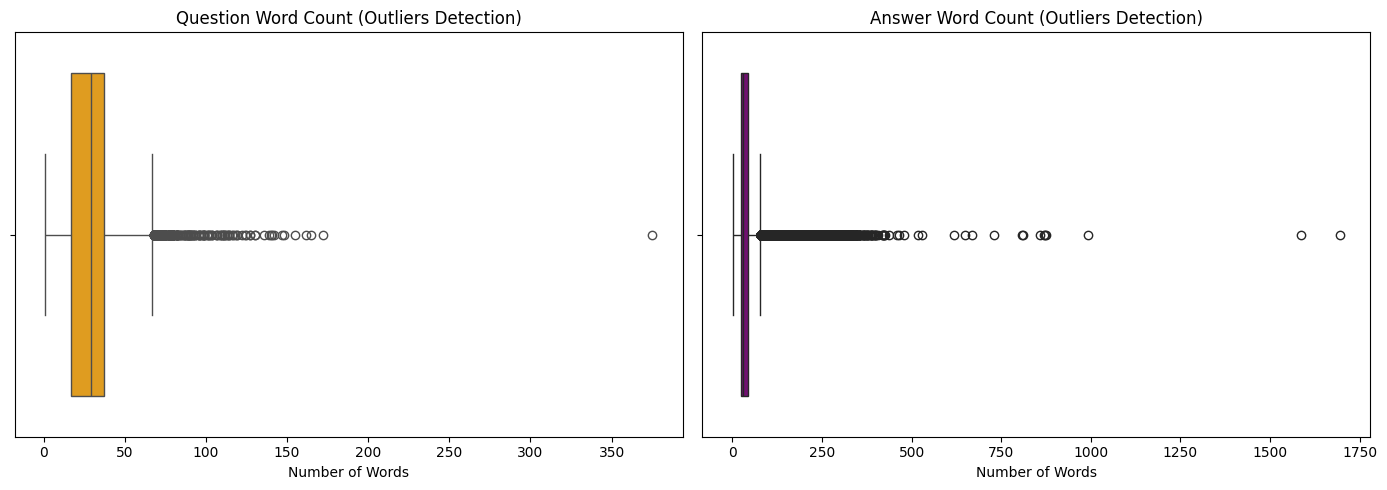

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure columns are defined
cols = df.columns
q_col = cols[0]
a_col = cols[1]

# 1. Word Count Analysis
print("Calculating word counts...")
df['question_word_count'] = df[q_col].astype(str).apply(lambda x: len(x.split()))
df['answer_word_count'] = df[a_col].astype(str).apply(lambda x: len(x.split()))

# 2. Visualize Word Count Distributions using Boxplots
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['question_word_count'], color='orange')
plt.title('Question Word Count (Outliers Detection)')
plt.xlabel('Number of Words')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['answer_word_count'], color='purple')
plt.title('Answer Word Count (Outliers Detection)')
plt.xlabel('Number of Words')

plt.tight_layout()
plt.show()



In [8]:
 #3. Duplicates Analysis
print("\n--- Duplicates Analysis ---")
total_exact_duplicates = df.duplicated().sum()
duplicate_questions = df.duplicated(subset=[q_col]).sum()

print(f"Total exact duplicate rows: {total_exact_duplicates}")
print(f"Total duplicate questions (same question repeated): {duplicate_questions}")




--- Duplicates Analysis ---
Total exact duplicate rows: 20059
Total duplicate questions (same question repeated): 21033


In [10]:

# 4. Outliers Investigation (Extremely short texts)
print("\n--- Outliers Investigation ---")
min_answer_words = df['answer_word_count'].min()
print(f"The shortest answer has {min_answer_words} word(s).")

if min_answer_words < 3:
    print("\nExamples of extremely short answers:")
    display(df[df['answer_word_count'] <= 3][[q_col, a_col, 'answer_word_count']].head())


--- Outliers Investigation ---
The shortest answer has 1 word(s).

Examples of extremely short answers:


,question,answer,answer_word_count
1053,\nكيفية التخلص من ارتفاع ضغط الدم ؟,None,1
1060,\nلدي فحمه لادنى مجهود\n,None,1
1171,\nعندي تلت اطفال وزني ٤٨ كتير ضعيفه بدي شو لاز...,None,1
2239,\nعلاج ارتفاع ضغط الدم 155/100,None,1
2435,\nما هو مرض اديسون,None,1


# Remove duplicate AND MISSING VALUES



In [13]:
# Remove exact duplicate rows
initial_count = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after_duplicates = len(df)

# Filter out rows with extremely short answers (less than 3 words)
# to ensure the model learns meaningful medical responses
df = df[df['answer_word_count'] >= 3].reset_index(drop=True)
final_count = len(df)

print(f"Initial row count: {initial_count}")
print(f"Count after removing duplicates: {after_duplicates}")
print(f"Final count after removing short answers: {final_count}")

Initial row count: 52758
Count after removing duplicates: 32699
Final count after removing short answers: 32598


#MAKE DATA VALID FOR FINE TUNING

In [14]:
from datasets import Dataset, DatasetDict

# Define the columns based on the dataset structure
# Assuming first column is Question and second is Answer
q_col = df.columns[0]
a_col = df.columns[1]

# Create a list of dictionaries in the ChatML format required by Qwen
formatted_data = []
for _, row in df.iterrows():
    formatted_data.append({
        "user": str(row[q_col]),
        "assistant": str(row[a_col])
    })

# Convert the cleaned Pandas DataFrame back to a Hugging Face Dataset object
clean_dataset = Dataset.from_list(formatted_data)

# Split into Training and Validation sets (90% Train, 10% Val)
final_dataset = clean_dataset.train_test_split(test_size=0.1)

print("Dataset successfully cleaned and split into:")
print(f"Training samples: {len(final_dataset['train'])}")
print(f"Validation samples: {len(final_dataset['test'])}")

Dataset successfully cleaned and split into:
Training samples: 29338
Validation samples: 3260


In [15]:
# Define final save path
clean_drive_path = "/content/drive/MyDrive/Medical_QA_Project_Cleaned"

# Save the DatasetDict to disk
final_dataset.save_to_disk(clean_drive_path)

print(f"Cleaned dataset saved successfully at: {clean_drive_path}")

Saving the dataset (0/1 shards):   0%|          | 0/29338 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3260 [00:00<?, ? examples/s]

Cleaned dataset saved successfully at: /content/drive/MyDrive/Medical_QA_Project_Cleaned


TEST BASE MODEL


In [19]:
# Install required libraries for quantization and fine-tuning
!pip install -U bitsandbytes>=0.46.1 transformers accelerate peft trl datasets

In [23]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Using the 0.5B model to show a clear difference after fine-tuning
model_id = "Qwen/Qwen2.5-0.5B-Instruct"

print("Loading the Small Base Model (0.5B)...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

print(f"Small model loaded. Memory footprint: {model.get_memory_footprint() / 1e6:.2f} MB")

Loading the Small Base Model (0.5B)...


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Small model loaded. Memory footprint: 988.07 MB


In [24]:
def generate_response(model, tokenizer, question, max_new_tokens=150):
    prompt = f"User: {question}\nAssistant:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    answer = full_output.split("Assistant:")[-1].strip()
    return answer

In [25]:
# Use the same sample questions
sample_questions = [
    "ما هي أعراض الانفلونزا الموسمية؟",
    "كيف يتم علاج نقص الحديد في الجسم؟",
    "ما هي الإسعافات الأولية للحروق البسيطة؟"
]

print("--- SMALL BASE MODEL RESPONSES (0.5B - Pre-Training) ---")
for q in sample_questions:
    print(f"\nQuestion: {q}")
    # We use the same generate_response function defined earlier
    print(f"Base Answer: {generate_response(model, tokenizer, q)}")
    print("-" * 30)

--- SMALL BASE MODEL RESPONSES (0.5B - Pre-Training) ---

Question: ما هي أعراض الانفلونزا الموسمية؟
Base Answer: الأعراض المصاحبة للانفلونزا الموسمية تشمل:

1. مادة حيوانية (الحمى) - يسببها الفيروسات مثل سلطة الكنز، والغذاء الخبيث.

2. التهاب الرئة - قد يسببه الفيروس أو البكتيريا.

3. التهاب العين - في بعض الحالات، يمكن أن يحدث.

4. التهاب اليدين والرفرف - في بعض الحالات، يمكن أن occurs.

5. الشعور بالتعب أو الحكة الشديدة.

6. نقص في الوزن أو الإصابة بالسكري.

7. صداع شديد.

8. تغيير
------------------------------

Question: كيف يتم علاج نقص الحديد في الجسم؟
Base Answer: نقص الحديد هو مشكلة صحية متعلقة بالفيتامين، وهو ضروري لصحة القلب والغدد الصماء. يساعد الفيتامين في تحسين صحة الجهاز العصبي المركزي وتنظيم الهرمونات. إليك بعض الخطوات التي يمكن أن تساعد في علاج النقص الحيواني:

1. تناول الأطعمة ذات الدورات الحيوانية مثل البيض أو الخبز.

2. اتباع نظام غذائي متوازن من الفوائد الغذائية.

3. استشارة الطبيب إذا كان لديك أي أعراض أخرى مثل السمنة، الشعور بالتعب، أو الانتفاخ
------------------

In [1]:
# Install specific, stable versions to prevent library conflicts
!pip install huggingface_hub==0.25.2 transformers==4.46.1 peft accelerate trl datasets

print("Libraries installed successfully. You can now proceed.")
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Using Qwen 0.5B to show clear improvement after training
model_id = "Qwen/Qwen2.5-0.5B-Instruct"

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

# Load Model in float16 (Full Precision)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)

print(f"Model loaded successfully. VRAM used: {model.get_memory_footprint() / 1e6:.2f} MB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.6/436.6 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.0/348.0 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: h

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully. VRAM used: 988.07 MB


In [7]:
from peft import LoraConfig, get_peft_model

# Define LoRA parameters for efficient fine-tuning
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# Apply LoRA to the model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [ ]:
from datasets import load_from_disk
from google.colab import drive

# 1. Ensure Google Drive is mounted
drive.mount('/content/drive')

# 2. Load the cleaned dataset
clean_drive_path = "/content/drive/MyDrive/Medical_QA_Project_Cleaned"
print("Loading the cleaned dataset from Google Drive...")
final_dataset = load_from_disk(clean_drive_path)

# 3. Create a formatting function for Causal Language Modeling
def format_prompt(example):
    # Combine User and Assistant text, adding the EOS token
    combined_text = f"User: {example['user']}\nAssistant: {example['assistant']}{tokenizer.eos_token}"
    return {"text": combined_text}

# 4. Apply the formatting
print("Formatting dataset...")
formatted_dataset = final_dataset.map(format_prompt)

print("Dataset loaded and formatted successfully!")

import os
from trl import SFTTrainer, SFTConfig

# 1. Define Drive path for checkpoints
drive_checkpoints_path = "/content/drive/MyDrive/Medical_Qwen_Checkpoints"
os.makedirs(drive_checkpoints_path, exist_ok=True)

# 2. Define Training Arguments
training_args = SFTConfig(
    output_dir=drive_checkpoints_path, # Saves directly to Google Drive
    dataset_text_field="text",
    max_seq_length=512,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    optim="adamw_torch",
    learning_rate=2e-4,
    num_train_epochs=10,
    save_strategy="epoch", # Checkpoint saved strictly at the end of each epoch
    logging_steps=10,
    fp16=True,
    report_to="none"
)

# 3. Initialize the Trainer
trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["test"],
    processing_class=tokenizer,
    args=training_args,
)

# 4. Start Fine-Tuning
print(f"Starting Standard LoRA Fine-Tuning for 10 Epochs...")
print(f"Checkpoints will be saved automatically to: {drive_checkpoints_path}")
trainer.train()

In [ ]:
import matplotlib.pyplot as plt

# Extract logging history to visualize convergence
history = trainer.state.log_history
train_loss = [x['loss'] for x in history if 'loss' in x]
steps = [x['step'] for x in history if 'loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss, label='Training Loss', color='blue', linewidth=2)
plt.title('Training Loss Curve (Model Convergence)')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()